In [10]:
import torch
import mylib
import numpy as np

from torch.utils import data

In [15]:
def synthetic_data(w, b, num_examples):
    # 构造随机数据y = Xw + b + e
    X = torch.normal(0, 1, (num_examples, len(w)))
    y = X @ w + b
    y += torch.normal(0, 0.01, y.shape)
    return X, y.reshape((-1,1))

def load_array(data_arrays, batch_size, is_train=True):
    """构造一个PyTorch数据迭代器"""
    # is_train表示是否希望数据迭代器对象在每个迭代周期内打乱数据
    dataset = data.TensorDataset(*data_arrays)
    return data.DataLoader(dataset, batch_size, shuffle=is_train)

def init_params():
    w = torch.normal(0, 1, size=(num_inputs, 1), requires_grad=True)
    b = torch.zeros(1, requires_grad=True)
    return [w, b]

def l2_penalty(w):
    return torch.sum(w.pow(2)) / 2

def l1_penalty(w):
    return (torch.abs(w)).sum()

def sgd(params, lr, batch_size):
    # 小批量随机梯度下降
    with torch.no_grad():
        for param in params:
            param -= lr * param.grad / batch_size
            param.grad.zero_()

def train(lambd):
    w, b = init_params()
    net = lambda X: X @ w + b
    loss = lambda y_hat, y: (y_hat - y.reshape(-1,1)) ** 2 / 2
    num_epochs, lr = 200, 0.003
    animator = mylib.Animator(xlabel='epochs', ylabel='loss', yscale='log', 
                              xlim=[5, num_epochs], legend=['train', 'test'])
    for epoch in range(num_epochs):
        for X, y in train_iter:
            l = loss(net(X), y) + lambd * l1_penalty(w)
            l.sum().backward()
            sgd([w, b], lr, batch_size)
        if (epoch + 1) % 5 == 0:
            animator.add(epoch + 1, (mylib.evaluate_loss(net, train_iter, loss),
                                     mylib.evaluate_loss(net, test_iter, loss)))
            
def train_lambdas(lambdas):
    w, b = init_params()
    net = lambda X: X @ w + b
    loss = lambda y_hat, y: (y_hat - y.reshape(-1,1)) ** 2 / 2
    num_epochs, lr = 200, 0.003
    animator = mylib.Animator(xlabel='lambda', ylabel='loss', yscale='log', 
                              xlim=[lambdas[0], lambdas[-1]], legend=['train', 'test'])
    for lambd in lambdas:
        for epoch in range(num_epochs):
            for X, y in train_iter:
                l = loss(net(X), y) + lambd * l1_penalty(w)
                l.sum().backward()
                sgd([w, b], lr, batch_size)
        animator.add(lambd, (mylib.evaluate_loss(net, train_iter, loss),
                             mylib.evaluate_loss(net, test_iter, loss)))
        

                                     


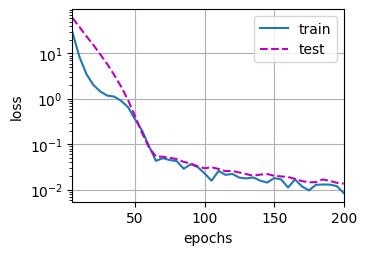

In [4]:
n_train, n_test, num_inputs, batch_size = 20, 100, 200, 5
true_w, true_b = torch.ones((num_inputs, 1)) * 0.01, 0.05
train_data = synthetic_data(true_w, true_b, n_train)
train_iter = load_array(train_data, batch_size)
test_data = synthetic_data(true_w, true_b, n_test)
test_iter = load_array(test_data, batch_size, is_train=False)

train(lambd=3)

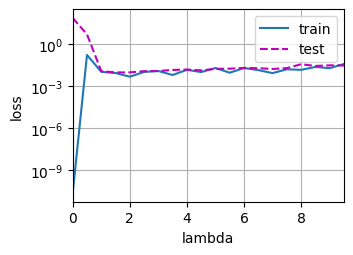

In [18]:
lambdas = np.arange(0, 10, 0.5)
train_lambdas(lambdas)